# Integration with Python - Part B - More advanced methods and SciPy tools

In [42]:
import numpy as np
import matplotlib.pyplot as plt

In this notebook we will continue our discussion of numerical integration (quadrature) using Python. We will explore more advanced algorithms and also the built-in tools in SciPy.

### Setup

In [43]:
def f(x):
    return x**4 - 2*x +1

In [44]:
integral_true = 4.4

In [45]:
# Define parameters for numerical integration
N = 10  # Number of slices
a = 0.0 # Lower bound
b = 2.0 # Upper bound
w = (b-a)/N # Step size
print("Step size ",w)

Step size  0.2


Let's define the midpoint and trapezoid methods just as we did last time.

In [46]:
def integral_midpoint(f,N,a,b):

    # Step size
    w = (b-a)/N

    # Create an array entry for each step
    x = np.linspace(a+w/2, b+w/2, N, endpoint = False)

    # Calculate numerical integral
    s=0
    for k in x:
        s+= f(k)*w
    return s

In [47]:
def integral_trapezoid(f,N,a,b):

    # Step size
    w = (b-a)/N

    # Calculate numerical integral
    #   using the extended trapezoid rule
    x = np.arange(1, N)
    s = 0.5*f(a) + 0.5*f(b)
    for k in x:
        s+= f(a+k*w)
    s = w*s
    return s

## Extended Simpsons method - Integration using polynomials

![Simpsons Animation](https://upload.wikimedia.org/wikipedia/commons/f/fc/Simpson%27s_One-Third_Rule.gif)

Now lets define the Extended Simpsons method.

Here is what we derived in class:

$I(a,b) = \frac{w}{3}[f(a)+f(b)+4\sum_{k \text{odd}}^{N-1} f(a+kw) + 2\sum_{k \text{even}}^{N-1} f(a+kw)]$

Where:
   * a = Lower Bound
   * b = Upper Bound
   * w = step width
   * N = Total number of steps (must be even)
   * k = Iteration value
   
Spend 10 minutes trying to code this in python on your own. If you want, you can scroll down and find the answer

$ $

$ $

$ $

$ $

$ $

Here is the answer:

In [48]:
def integral_simpsons(f,N,a,b):

    if N%2!=0:
        print("Please choose N even")
        raise ValueError

    # Step size
    w = (b-a)/N

    # Calculate numerical integral
    #   using the extended trapezoid rule

    # Add together function values at end points
    s = f(a) + f(b)

    # Add together function values at odd iterations excluding endpoints
    #   with weight 4
    x = np.arange(1, N, 2)
    for k in x:
        s+= 4*f(a+k*w)

    # Add together function values at even iterations excluding endpoints
    #   with weight 4
    x = np.arange(2, N, 2)
    for k in x:
        s+= 2*f(a+k*w)

    # Multiply all sums by step width divided by 3
    integral = w * s / 3

    return integral

In [49]:
# Do the same thing but without a loop (vectorized)
def integral_simpsons_vec(f, N, a, b):

    if N % 2 != 0:
        print("Please choose N even")
        raise ValueError("N must be an even number for Simpson's rule.")

    # Step size
    w = (b - a) / N

    # Create array of all x points (including endpoints)
    x = np.linspace(a, b, N + 1)

    # Calculate all y values at once
    y = f(x)

    # Apply Simpson's rule weights using array slicing and sum
    #   Endpoints y[0] and y[-1] have weight 1
    #   np.sum(y[1:-1:2]) sums elements with odd indices excluding endpoints. We then apply weight 4 to this sum.
    #   np.sum(y[2:-1:2]) sums elements with even indices excluding endpoints. We then apply weight 2 to this sum.
    s = y[0] + y[-1] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-1:2])

    # Multiply by step width divided by 3
    integral = w * s / 3

    return integral


In [50]:
integral_simpsons(f,6,0,2)

np.float64(4.403292181069957)

In [51]:
integral_simpsons_vec(f,6,0,2)

np.float64(4.403292181069958)

In [52]:
def make_value_vs_N_array(integral_func):
    N_array = np.arange(2,100,2,dtype='int64')
    integral_results= []
    for N in N_array:
        integral_results.append(integral_func(f,N,a,b))
    return N_array, integral_results

In [53]:
def percent_error(a,s_true):
    return (np.array(a)-s_true)/s_true

In [54]:
N_array, mid = make_value_vs_N_array(integral_midpoint)
N_array, tra = make_value_vs_N_array(integral_trapezoid)
N_array, sim = make_value_vs_N_array(integral_simpsons)

(4.3, 4.5)

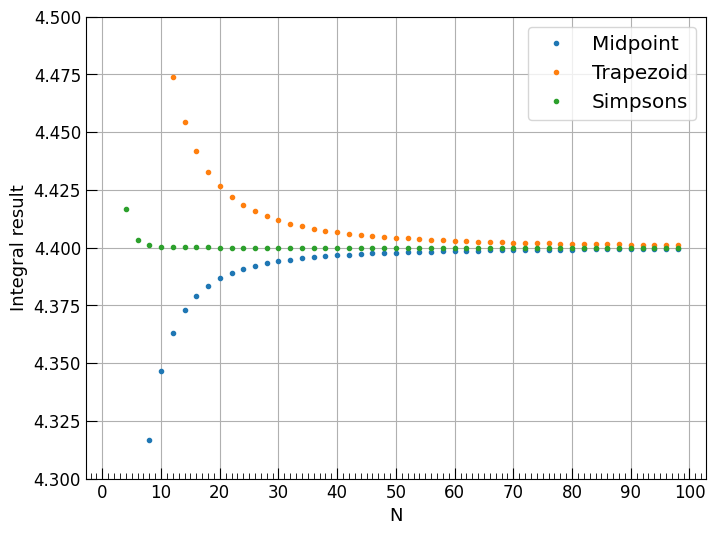

In [55]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(N_array,mid,".",label="Midpoint")
ax.plot(N_array,tra,".",label="Trapezoid")
ax.plot(N_array,sim,".",label="Simpsons")
ax.grid(True)
ax.legend(loc='upper right', fontsize='x-large')
ax.set_xlabel("N", fontsize=13)
ax.set_ylabel("Integral result", fontsize=13)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis='both', which='major', length=8, labelsize=12,  direction = "in")
ax.tick_params(axis='both', which='minor', length=4, direction = "in")
ax.set_ylim(4.3,4.5)


In [56]:
mid_pe = percent_error(mid,integral_true)
tra_pe = percent_error(tra,integral_true)
sim_pe = percent_error(sim,integral_true)

(-0.1, 0.1)

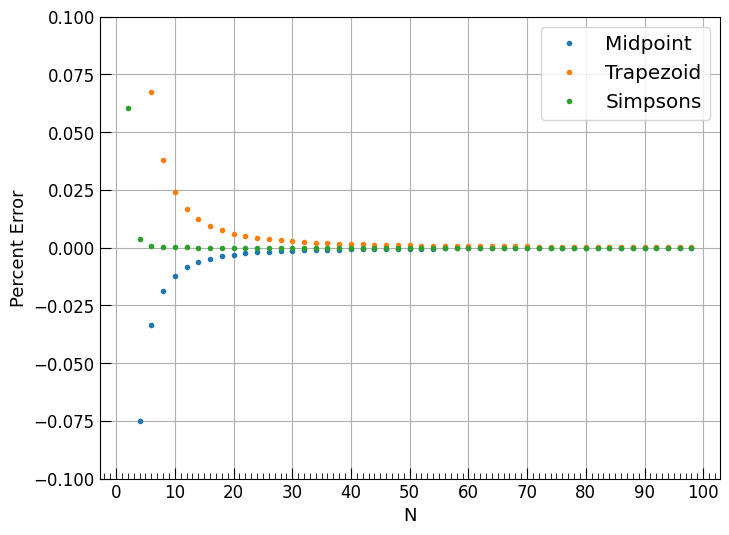

In [57]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(N_array,mid_pe,".",label="Midpoint")
ax.plot(N_array,tra_pe,".",label="Trapezoid")
ax.plot(N_array,sim_pe,".",label="Simpsons")
ax.grid(True)
ax.legend(loc='upper right', fontsize='x-large')
ax.set_xlabel("N", fontsize=13)
ax.set_ylabel("Percent Error", fontsize=13)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis='both', which='major', length=8, labelsize=12,  direction = "in")
ax.tick_params(axis='both', which='minor', length=4, direction = "in")
ax.set_ylim(-0.1,0.1)


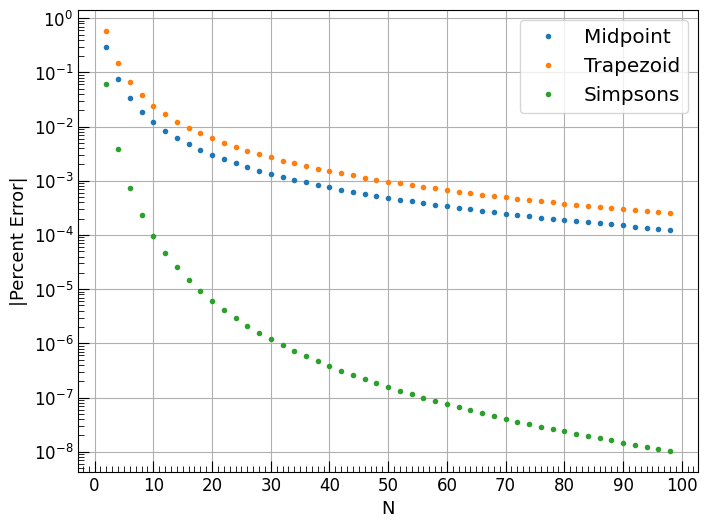

In [58]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(N_array,np.fabs(mid_pe),".",label="Midpoint")
ax.plot(N_array,np.fabs(tra_pe),".",label="Trapezoid")
ax.plot(N_array,np.fabs(sim_pe),".",label="Simpsons")
ax.grid(True)
ax.legend(loc='upper right', fontsize='x-large')
ax.set_xlabel("N", fontsize=13)
ax.set_ylabel("|Percent Error|", fontsize=13)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis='both', which='major', length=8, labelsize=12,  direction = "in")
ax.tick_params(axis='both', which='minor', length=4, direction = "in")
plt.yscale('log')

## Newton-Cotes (family of methods)

We've seen how the Trapezoidal Rule approximates the area under a curve using straight lines connecting points, and how Simpson's Rule uses parabolas for a potentially better fit.  These are actually the first two members of a larger family of numerical integration techniques called Newton-Cotes formulas.

The core idea behind all Newton-Cotes methods is the same: replace the function you want to integrate with a simpler polynomial that passes through several equally spaced points within the integration interval. Then, integrate this simpler polynomial exactly.

The Trapezoidal Rule uses a 1st-degree polynomial (a line) through 2 points (n=1).

Simpson's 1/3 Rule uses a 2nd-degree polynomial (a parabola) through 3 points (n=2).

Higher-order rules, like Simpson's 3/8 (cubic fit, 4 points, n=3) and Boole's Rule (quartic fit, 5 points, n=4), use higher-degree polynomials for potentially even greater accuracy, although they come with stricter requirements on the number of intervals used in their extended forms (Simpson's requires N even, Simpson's 3/8 requires N a multiple of 3, Boole requires N a multiple of 4).

These formulas provide a systematic way to improve integration accuracy by using increasingly complex polynomial approximations. Deriving them is more difficult (although it is the same idea as what we did for Simpson), but code the implementation is too much more difficult:




| Degree (n) | Rule Name         | Basic Formula (Integral from $x_0$ to $x_n$)                      | Extended Formula (Integral from $a=x_0$ to $b=x_N$)                                                                       | Error Order (Extended) | N Requirement |
|------------|-------------------|-------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------|------------------------|---------------|
| 1          | Trapezoidal Rule  | $\frac{w}{2}(f_0 + f_1)$                                          | $\frac{w}{2}(f_0 + 2\sum_{i=1}^{N-1} f_i + f_N)$                                                                        | $O(w^2)$               | Any N $\ge$ 1 |
| 2          | Simpson's 1/3 Rule| $\frac{w}{3}(f_0 + 4f_1 + f_2)$                                   | $\frac{w}{3}(f_0 + 4\sum_{i=1, \text{odd}}^{N-1} f_i + 2\sum_{i=2, \text{even}}^{N-2} f_i + f_N)$                       | $O(w^4)$               | N must be even |
| 3          | Simpson's 3/8 Rule| $\frac{3w}{8}(f_0 + 3f_1 + 3f_2 + f_3)$                           | $\frac{3w}{8}(f_0 + 3\sum_{i=1,4,7,\dots}^{N-2} (f_i+f_{i+1}) + 2\sum_{i=3,6,9,\dots}^{N-3} f_i + f_N)$               | $O(w^4)$               | N multiple of 3 |
| 4          | Boole's Rule      | $\frac{2w}{45}(7f_0 + 32f_1 + 12f_2 + 32f_3 + 7f_4)$              | $\frac{2w}{45}(7f_0 + 32\sum_{i=1,5,\dots}^{N-3}f_i + 12\sum_{i=2,6,\dots}^{N-2}f_i + 14\sum_{i=4,8,\dots}^{N-4}f_i + \dots + 7f_N)$ | $O(w^6)$               | N multiple of 4 |


In [59]:
def integral_simpsons_38(f, N, a, b):
    """
    Calculates the definite integral of a function f from a to b
    using the extended Simpson's 3/8 rule (n=3) with N slices, using loops.
    """
    if N % 3 != 0:
        raise ValueError("N must be a multiple of 3 for Simpson's 3/8 rule.")

    w = (b - a) / N
    s = f(a) + f(b) # Start with endpoints

    # Sum terms with weight 3 (indices 1, 2, 4, 5, 7, 8, ...)
    for k in range(1, N):
        if k % 3 != 0: # Exclude indices that are multiples of 3
            s += 3 * f(a + k * w)

    # Sum terms with weight 2 (indices 3, 6, 9, ...)
    for k in range(3, N, 3):
        s += 2 * f(a + k * w)

    integral = (3 * w / 8) * s
    return integral


def integral_simpsons_38_vec(f, N, a, b):
    """
    Calculates the definite integral of a function f from a to b
    using a vectorized version of the extended Simpson's 3/8 rule (n=3)
    with N slices.
    """
    if N % 3 != 0:
        raise ValueError("N must be a multiple of 3 for Simpson's 3/8 rule.")

    w = (b - a) / N
    x = np.linspace(a, b, N + 1)
    y = f(x)

    # Apply Simpson's 3/8 rule weights using array slicing and sum
    # Weights: 1, 3, 3, 2, 3, 3, 2, ..., 3, 3, 1
    s = (y[0] + y[-1] +
         3 * np.sum(y[1:-1:3]) +  # Indices 1, 4, 7...
         3 * np.sum(y[2:-1:3]) +  # Indices 2, 5, 8...
         2 * np.sum(y[3:-1:3]))   # Indices 3, 6, 9... (Exclude endpoints handled above)

    # Corrected calculation for vectorized sum:
    # Need to sum all non-multiple-of-3 indices with weight 3,
    # and multiple-of-3 indices (excluding endpoints) with weight 2.
    indices_all = np.arange(1, N)
    indices_mult_3 = np.arange(3, N, 3)
    indices_non_mult_3 = np.setdiff1d(indices_all, indices_mult_3)

    s_vec = y[0] + y[-1]
    s_vec += 3 * np.sum(y[indices_non_mult_3])
    s_vec += 2 * np.sum(y[indices_mult_3])


    integral = (3 * w / 8) * s_vec # Use corrected sum s_vec
    return integral

# --- Boole's Rule (n=4, Original and Vectorized) ---

def integral_boole(f, N, a, b):
    """
    Calculates the definite integral of a function f from a to b
    using the extended Boole's rule (n=4) with N slices, using loops.
    """
    if N % 4 != 0:
        raise ValueError("N must be a multiple of 4 for Boole's rule.")

    w = (b - a) / N
    s = 7 * (f(a) + f(b)) # Start with weighted endpoints

    # Loop through interior points applying weights 32, 12, 32, 14 pattern
    for k in range(1, N):
        x_k = a + k * w
        if k % 4 == 1:    # Indices 1, 5, 9...
            s += 32 * f(x_k)
        elif k % 4 == 2:  # Indices 2, 6, 10...
            s += 12 * f(x_k)
        elif k % 4 == 3:  # Indices 3, 7, 11...
            s += 32 * f(x_k)
        elif k % 4 == 0:  # Indices 4, 8, 12... (connecting points)
            s += 14 * f(x_k)

    integral = (2 * w / 45) * s
    return integral


def integral_boole_vec(f, N, a, b):
    """
    Calculates the definite integral of a function f from a to b
    using a vectorized version of the extended Boole's rule (n=4)
    with N slices.
    """
    if N % 4 != 0:
        raise ValueError("N must be a multiple of 4 for Boole's rule.")

    w = (b - a) / N
    x = np.linspace(a, b, N + 1)
    y = f(x)

    # Apply Boole's rule weights using array slicing and sum
    s = (7 * (y[0] + y[-1]) +       # Endpoints
         32 * np.sum(y[1:-1:4]) +  # Indices 1, 5, 9...
         12 * np.sum(y[2:-1:4]) +  # Indices 2, 6, 10...
         32 * np.sum(y[3:-1:4]) +  # Indices 3, 7, 11...
         14 * np.sum(y[4:-1:4]))   # Indices 4, 8, 12... (connecting points)

    integral = (2 * w / 45) * s
    return integral

In [60]:
# For this to work with simposon, simpson38, and boole N must be a multiple of 12

def make_value_vs_N_array_lcm12(integral_func, N_max, a, b, N_min=12):
    """
    Generates N values (multiples of 12) up to N_max and calculates
    the integral for each N using the provided integration function.
    """

    if N_min < 12 or N_min % 12 != 0:
         raise ValueError("N_min must be >= 12 and a multiple of 12.")

    # Generate N values that are multiples of 12
    N_array = np.arange(N_min, N_max + 1, 12, dtype='int64')
    integral_results = []
    for N_val in N_array:
        integral_results.append(integral_func(f, N_val, a, b))
    return N_array, integral_results


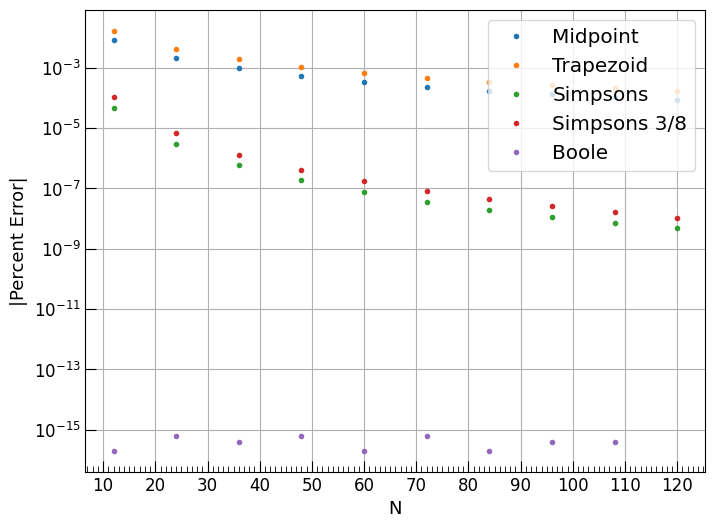

In [61]:
N_max_plot = 120
a_bound = a
N_array, midpo = make_value_vs_N_array_lcm12(integral_midpoint, N_max_plot, a, b)
N_array, trape = make_value_vs_N_array_lcm12(integral_trapezoid, N_max_plot, a, b)
N_array, simps = make_value_vs_N_array_lcm12(integral_simpsons, N_max_plot, a, b)
N_array, sim38 = make_value_vs_N_array_lcm12(integral_simpsons_38, N_max_plot, a, b)
N_array, boole = make_value_vs_N_array_lcm12(integral_boole, N_max_plot, a, b)

midpo_pe = percent_error(midpo,integral_true)
trape_pe = percent_error(trape,integral_true)
simps_pe = percent_error(simps,integral_true)
sim38_pe = percent_error(sim38,integral_true)
boole_pe = percent_error(boole,integral_true)

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(N_array,np.fabs(midpo_pe),".",label="Midpoint")
ax.plot(N_array,np.fabs(trape_pe),".",label="Trapezoid")
ax.plot(N_array,np.fabs(simps_pe),".",label="Simpsons")
ax.plot(N_array,np.fabs(sim38_pe),".",label="Simpsons 3/8")
ax.plot(N_array,np.fabs(boole_pe),".",label="Boole")
ax.grid(True)
ax.legend(loc='upper right', fontsize='x-large')
ax.set_xlabel("N", fontsize=13)
ax.set_ylabel("|Percent Error|", fontsize=13)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis='both', which='major', length=8, labelsize=12,  direction = "in")
ax.tick_params(axis='both', which='minor', length=4, direction = "in")
plt.yscale('log')

Our example function we are fiting is quartic. Since Boole's rule (n=4) approximates the function using a 4th-degree (quartic) polynomial fit through 5 points, Boole's rule will integrate it exactly, within the limits of computer floating-point arithmetic.

So, any small error you might observe when applying Boole's rule to a pure quartic function would indeed be due to rounding errors in the calculations, not the approximation method itself.

## Gaussian Quadriture - Integration using Legendre Polynomials





Gaussian quadrature is a powerful method for numerical integration. It is extraordinaryly efficiency. For a given number of function evaluations, Gaussian quadrature achieves a much higher degree of accuracy than other common methods like the Trapezoidal Rule or Simpson's Rule.

Lets remind ourselves:

1.  Midpoint Rule: You pick one point (the middle) and multiply its height by the total width. That's like saying the function is flat. It works okay if the function is nearly flat.

2.  Trapezoid Rule: You use two points (the ends) for each trapezoid. You average their heights and multiply by the width. That's like saying the function is a straight line between the points. Better, but misses curves. Extending the trapezoid rule we get an array of evenly spaced points where we sum the value of the function at that location times a coefficient (with different coefficients on the endpoints).

3.  Simpson's Rule: For each quadratic fit you use three fixed points (ends and middle). You combine their heights with specific weights (1/3 for ends, 4/3 for middle, times width/2) that perfectly capture the area if the curve were a parabola through those points. This is much better for curves. The extended simpson's rule again gives us an array of evenly spaced points where we sum the value of the function at each point times a coefficient (with different coefficients on the endpoints and different coefficients for even and odd points).

**The Gaussian Idea**
  * Simpson's rule improved things by using 3 points and special weights. But the locations (ends, middle) were still fixed.
  * The big idea of Gaussian Quadrature is: **What if we could choose *both* the locations AND the weights freely?**
  * If we use, say, 3 points, we now have 6 things we can adjust:
      * The location of point 1 ($x_1$)
      * The location of point 2 ($x_2$)
      * The location of point 3 ($x_3$)
      * The weight (importance) of point 1 ($w_1$)
      * The weight (importance) of point 2 ($w_2$)
      * The weight (importance) of point 3 ($w_3$)

  * We want to choose these 6 things ($x_1, x_2, x_3, w_1, w_2, w_3$) so that our simple formula gives the exact right answer for the highest possible degree polynomial.

      * Area $\approx w_1 \times f(x_1) + w_2 \times f(x_2) + w_3 \times f(x_3)$


  *  Mathematicians (like Gauss) figured out exactly how to do this!
      * They discovered that the "magic" locations to pick (for the interval -1 to 1) are the places where a special polynomial called the **Legendre Polynomial** crosses the x-axis. For 3 points, you use the 3rd Legendre polynomial. These points aren't evenly spaced; they tend to be bunched a bit more towards the ends.
      * Legendre Polynoials are orthogonal. The integral of the product of any two different Legendre polynomials over $[-1, 1]$ is zero.
      * They also found a related formula to calculate the exact weight needed for each of these special points. It turns out points closer to the middle get a bit more weight than points near the ends for the 3-point rule.

**Why does this specific choice work?**

Newman demonstrates this in the appendix of the book.
These Legendre polynomials and their roots have very special mathematical properties. Choosing the roots as the sample points, and using the associated weights, makes all the errors cancel out perfectly if the function you are integrating is a polynomial up to degree $2n-1$ (degree 5 for 3 points).



Gaussian Quadrature is an optimal strategy for sampling and weighting, specifically designed to be incredibly accurate for polynomials, which makes it very accurate for most smooth functions.

### Legendre Polynomials

The Legendre Polynomials are a set of special polynomials which have applications in many fields. Their most important feature is that they are orthogonal: the integral of the product of any two different Legendre polynomials over $[-1, 1]$ is zero.  They appear naturally as solutions to certain differential equations in physics (especially in problems with spherical symmetry) and are crucial in numerical methods like Gaussian quadrature, where their roots are used as the optimal points for integration.

![Legendre1](https://solitaryroad.com/c679/ole2.gif)



Let's experiment with drawing them and their roots. Lets's also draw how the weights are calculated for N=3 using Legendre Basis Polynomials. The basis polynomials have the special property that they are equal to 1 at one root location and equal to zero at the other two root locations.

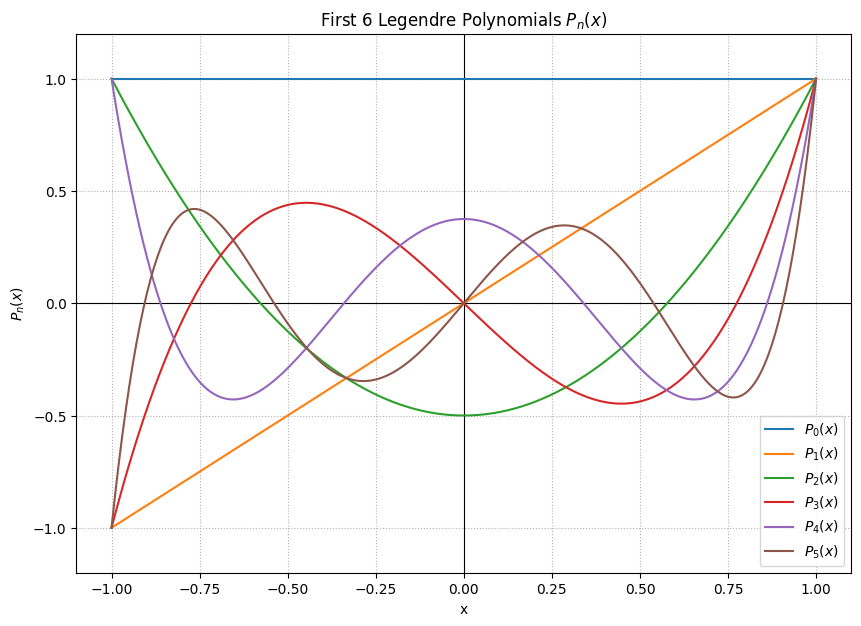

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def legendre_poly(N, x):
    """
    Calculates the Nth Legendre polynomial P_N(x) using the recurrence relation.

    Args:
        N (int): The degree of the Legendre polynomial.
        x (np.ndarray or float): The point(s) at which to evaluate the polynomial.

    Returns:
        np.ndarray or float: The value(s) of P_N(x).
    """
    if N == 0:
        # P_0(x) = 1
        # Use np.ones_like to handle both single values and arrays for x
        return np.ones_like(x)
    elif N == 1:
        # P_1(x) = x
        return x
    else:
        # P_k values for k=0 and k=1
        p0 = np.ones_like(x)
        p1 = x
        # Apply recurrence relation: (k+1)P_{k+1} = (2k+1)xP_k - kP_{k-1}
        # Iterate from k=1 up to N-1 to find P_N
        for k in range(1, N):
            p_next = ((2*k + 1) * x * p1 - k * p0) / (k + 1)
            p0, p1 = p1, p_next # Update p_{k-1} and p_k for the next iteration
        # After the loop, p1 holds the value of P_N(x)
        return p1

# Plotting
x = np.linspace(-1, 1, 400) # Points for smooth curves on the interval [-1, 1]
max_degree = 5 # Plot polynomials up to this degree

plt.figure(figsize=(10, 7))
plt.axhline(0, color='black', linewidth=0.8) # Draw x-axis
plt.axvline(0, color='black', linewidth=0.8) # Draw y-axis

# Loop and plot
for n in range(max_degree + 1):
    y = legendre_poly(n, x)
    plt.plot(x, y, label=f'$P_{{{n}}}(x)$') # Plot P_n(x) with LaTeX label

plt.title(f'First {max_degree+1} Legendre Polynomials $P_n(x)$')
plt.xlabel('x')
plt.ylabel('$P_n(x)$')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':')
plt.ylim(-1.2, 1.2) # Set y-axis limits suitable for Legendre polynomials
plt.show()


<>:152: SyntaxWarning: invalid escape sequence '\e'
<>:162: SyntaxWarning: invalid escape sequence '\i'
<>:169: SyntaxWarning: invalid escape sequence '\e'
<>:169: SyntaxWarning: invalid escape sequence '\e'
<>:171: SyntaxWarning: invalid escape sequence '\e'
<>:152: SyntaxWarning: invalid escape sequence '\e'
<>:162: SyntaxWarning: invalid escape sequence '\i'
<>:169: SyntaxWarning: invalid escape sequence '\e'
<>:169: SyntaxWarning: invalid escape sequence '\e'
<>:171: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-3853993600.py:152: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(x_plot, lj_y, label=f'$\ell_{{{j}}}(x)$', color=colors_lagrange[j])
/tmp/ipython-input-3853993600.py:162: SyntaxWarning: invalid escape sequence '\i'
  plt.text(x_pos, y_pos, f'$w_{{{j}}} = \int \ell_{{{j}}} dx$\n  $= {weight_calc:.4f}$',
/tmp/ipython-input-3853993600.py:169: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Lagrange Basis Polynomials $\ell_j(x)$ for N={N_weig

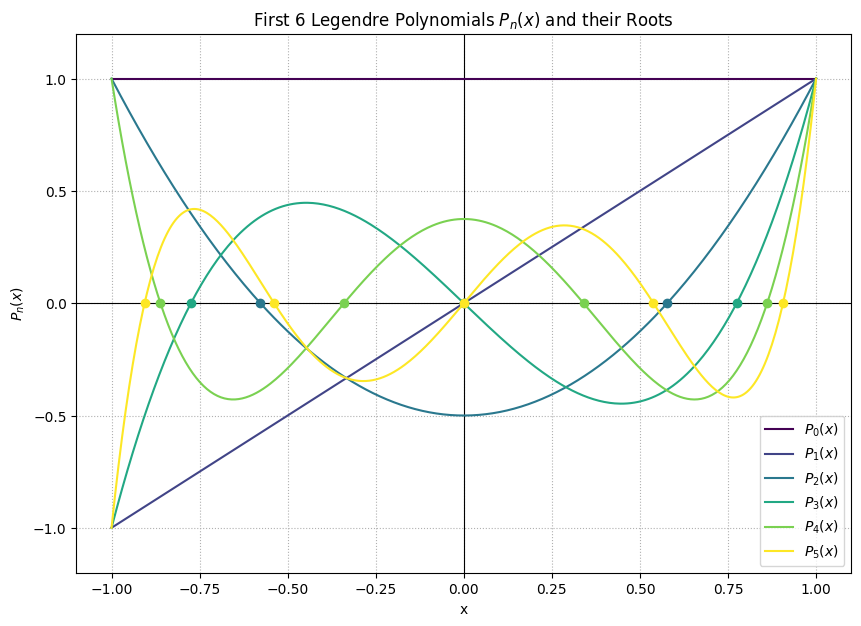

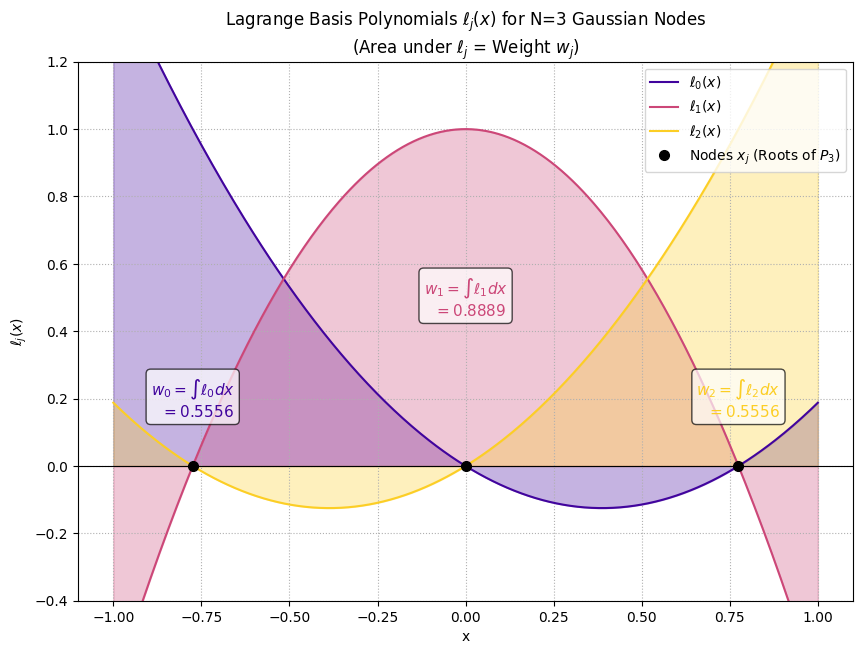


--- Weights Calculation for N=3 ---
Nodes (Roots of P_3): [-0.77459667  0.          0.77459667]
Calculated Weights from gaussxw: [0.55555556 0.88888889 0.55555556]
Note how the calculated weights match the shaded areas (integrals of basis polynomials).


In [63]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import ones,copy,cos,tan,pi,linspace
from scipy.integrate import quad # Needed for integrating Lagrange polynomials

def legendre_poly(N, x):
    """
    Calculates the Nth Legendre polynomial P_N(x) using the recurrence relation.

    Args:
        N (int): The degree of the Legendre polynomial.
        x (np.ndarray or float): The point(s) at which to evaluate the polynomial.

    Returns:
        np.ndarray or float: The value(s) of P_N(x).
    """
    if N == 0:
        # P_0(x) = 1
        return np.ones_like(x)
    elif N == 1:
        # P_1(x) = x
        return x
    else:
        # P_k values for k=0 and k=1
        p0 = np.ones_like(x)
        p1 = x
        # Apply recurrence relation: (k+1)P_{k+1} = (2k+1)xP_k - kP_{k-1}
        # Iterate from k=1 up to N-1 to find P_N
        for k in range(1, N):
            p_next = ((2*k + 1) * x * p1 - k * p0) / (k + 1)
            p0, p1 = p1, p_next # Update p_{k-1} and p_k for the next iteration
        # After the loop, p1 holds the value of P_N(x)
        return p1

def gaussxw_nodes_weights(N):
    """
    Calculates the roots (nodes) x_g and weights w_g of the Nth Legendre
    polynomial P_N(x) on the interval [-1, 1].

    Args:
        N (int): The degree of the Legendre polynomial (number of points).

    Returns:
        tuple: (np.ndarray roots, np.ndarray weights) sorted by roots.
    """
    # Uses the core logic from Mark Newman's gaussxw to find roots
    a_g = linspace(3,4*N-1,N)/(4*N+2)
    x_g = cos(pi*a_g+1/(8*N*N*tan(a_g)))
    epsilon = 1e-15
    delta = 1.0
    # Find roots using Newton's method
    while delta>epsilon:
        p0 = ones(N,float)
        p1 = copy(x_g)
        for k in range(1,N):
            p_next = ((2*k+1)*x_g*p1 - k*p0)/(k+1)
            p0, p1 = p1, p_next
        # Calculate the derivative P'_N(x) using a property of Legendre Polynomials
        # P'_N(x) = N * (P_{N-1}(x) - x*P_N(x)) / (1 - x^2)
        x_g_clipped = np.clip(x_g, -1 + epsilon, 1 - epsilon) # Avoid division by zero at endpoints
        dp = (N)*(p0 - x_g * p1) / (1 - x_g_clipped * x_g_clipped)
        dp[dp == 0] = epsilon # Avoid division by zero if derivative is zero
        dx = p1/dp # p1 is P_N(x), which should be close to 0 at roots
        x_g -= dx
        x_g = np.clip(x_g, -1.0, 1.0) # Keep nodes within the interval
        delta = max(abs(dx))

    # Calculate weights using the formula: w_i = 2 / ((1 - x_i^2) * [P'_N(x_i)]^2)
    x_g_clipped = np.clip(x_g, -1 + epsilon, 1 - epsilon) # Avoid division by zero at endpoints
    p0 = ones(N, float)
    p1 = copy(x_g)
    for k in range(1, N): # Recalculate P_{N-1} (p0) and P_N (p1) at the final roots x_g
         p_next = ((2 * k + 1) * x_g * p1 - k * p0) / (k + 1)
         p0, p1 = p1, p_next
    dp = (N)*(p0 - x_g * p1) / (1 - x_g_clipped * x_g_clipped)
    dp[dp == 0] = epsilon # Avoid division by zero
    inner_dp_sq = dp*dp
    inner_dp_sq[inner_dp_sq <= 0] = epsilon # Ensure positive values for denominator
    denominator_term_1_minus_xsq = 1 - x_g_clipped*x_g_clipped
    denominator_term_1_minus_xsq[denominator_term_1_minus_xsq <= 0] = epsilon # Ensure positive values
    w_g = 2 / (denominator_term_1_minus_xsq * inner_dp_sq)

    # Sort nodes and corresponding weights
    sort_indices = np.argsort(x_g)
    return x_g[sort_indices], w_g[sort_indices]

def lagrange_basis(x, nodes, j):
    """
    Calculates the j-th Lagrange basis polynomial for the given nodes
    evaluated at point(s) x.

    Args:
        x (np.ndarray or float): Point(s) to evaluate the polynomial at.
        nodes (np.ndarray): The set of interpolation nodes (roots).
        j (int): The index of the basis polynomial to calculate (0 to N-1).

    Returns:
        np.ndarray or float: The value(s) of l_j(x).
    """
    xj = nodes[j]
    lj = np.ones_like(x, dtype=float)
    for k in range(len(nodes)):
        if k != j:
            xk = nodes[k]
            lj *= (x - xk) / (xj - xk)
    return lj

# --- Plotting Setup ---
x_plot = np.linspace(-1, 1, 400) # Points for smooth curves on the interval [-1, 1]
max_degree = 5 # Plot polynomials up to this degree

plt.figure(figsize=(10, 7))
plt.axhline(0, color='black', linewidth=0.8) # Draw x-axis
plt.axvline(0, color='black', linewidth=0.8) # Draw y-axis

# --- Loop and Plot Polynomials and Roots ---
colors = plt.cm.viridis(np.linspace(0, 1, max_degree + 1)) # Use a colormap

for n in range(max_degree + 1):
    y = legendre_poly(n, x_plot)
    line, = plt.plot(x_plot, y, label=f'$P_{{{n}}}(x)$', color=colors[n]) # Plot P_n(x) with LaTeX label

    # Calculate and plot roots for n > 0
    if n > 0:
        roots, _ = gaussxw_nodes_weights(n) # We only need roots here
        # Plot roots on the x-axis using the same color as the polynomial line
        plt.plot(roots, np.zeros_like(roots), 'o', color=line.get_color(), markersize=6)

# --- Add Plot Details ---
plt.title(f'First {max_degree+1} Legendre Polynomials $P_n(x)$ and their Roots')
plt.xlabel('x')
plt.ylabel('$P_n(x)$')
# Adjust legend position for better visibility
plt.legend(loc='lower right', bbox_to_anchor=(1, 0))
plt.grid(True, linestyle=':')
plt.ylim(-1.2, 1.2) # Set y-axis limits suitable for Legendre polynomials
plt.show()


# --- Visualization for Weights (N=3 Example) ---
N_weights = 3
nodes_w, weights_w = gaussxw_nodes_weights(N_weights)

plt.figure(figsize=(10, 7))
plt.axhline(0, color='black', linewidth=0.8)

# Plot Lagrange basis polynomials and shade areas
colors_lagrange = plt.cm.plasma(np.linspace(0.1, 0.9, N_weights))

for j in range(N_weights):
    lj_y = lagrange_basis(x_plot, nodes_w, j)
    plt.plot(x_plot, lj_y, label=f'$\ell_{{{j}}}(x)$', color=colors_lagrange[j])
    plt.fill_between(x_plot, lj_y, 0, color=colors_lagrange[j], alpha=0.3)

    # Calculate the integral (weight) using scipy quad
    weight_calc, _ = quad(lambda x: lagrange_basis(x, nodes_w, j), -1, 1)

    # Annotate the calculated weight (should match weights_w[j])
    # Place text strategically
    y_pos = 0.5 if j == 1 else 0.2 # Adjust y position for center vs side polynomials
    x_pos = nodes_w[j]
    plt.text(x_pos, y_pos, f'$w_{{{j}}} = \int \ell_{{{j}}} dx$\n  $= {weight_calc:.4f}$',
             ha='center', va='center', fontsize=11, color=colors_lagrange[j],
             bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))

# Mark the nodes on the x-axis
plt.plot(nodes_w, np.zeros(N_weights), 'ko', markersize=7, label='Nodes $x_j$ (Roots of $P_3$)')

plt.title(f'Lagrange Basis Polynomials $\ell_j(x)$ for N={N_weights} Gaussian Nodes\n(Area under $\ell_j$ = Weight $w_j$)')
plt.xlabel('x')
plt.ylabel('$\ell_j(x)$')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':')
plt.ylim(-0.4, 1.2)
plt.show()

print(f"\n--- Weights Calculation for N={N_weights} ---")
print(f"Nodes (Roots of P_{N_weights}): {nodes_w}")
print(f"Calculated Weights from gaussxw: {weights_w}")
print("Note how the calculated weights match the shaded areas (integrals of basis polynomials).")




Here are the Gaussian Quadrature functions provided by Mark Newman within his textbook "Computational Physics"

In [64]:
######################################################################
#
# Functions to calculate integration points and weights for Gaussian
# quadrature
#
# x,w = gaussxw(N) returns integration points x and integration
#           weights w such that sum_i w[i]*f(x[i]) is the Nth-order
#           Gaussian approximation to the integral int_{-1}^1 f(x) dx
# x,w = gaussxwab(N,a,b) returns integration points and weights
#           mapped to the interval [a,b], so that sum_i w[i]*f(x[i])
#           is the Nth-order Gaussian approximation to the integral
#           int_a^b f(x) dx
#
# This code finds the zeros of the nth Legendre polynomial using
# Newton's method, starting from the approximation given in Abramowitz
# and Stegun 22.16.6.  The Legendre polynomial itself is evaluated
# using the recurrence relation given in Abramowitz and Stegun
# 22.7.10.  The function has been checked against other sources for
# values of N up to 1000.  It is compatible with version 2 and version
# 3 of Python.
#
# Written by Mark Newman <mejn@umich.edu>, June 4, 2011
# You may use, share, or modify this file freely
#
######################################################################

from numpy import ones,copy,cos,tan,pi,linspace

def gaussxw(N):

    # Initial approximation to roots of the Legendre polynomial
    a = linspace(3,4*N-1,N)/(4*N+2)
    x = cos(pi*a+1/(8*N*N*tan(a)))

    # Find roots using Newton's method
    epsilon = 1e-15
    delta = 1.0
    while delta>epsilon:
        p0 = ones(N,float)
        p1 = copy(x)
        for k in range(1,N):
            p0,p1 = p1,((2*k+1)*x*p1-k*p0)/(k+1)
        dp = (N+1)*(p0-x*p1)/(1-x*x)
        dx = p1/dp
        x -= dx
        delta = max(abs(dx))

    # Calculate the weights
    w = 2*(N+1)*(N+1)/(N*N*(1-x*x)*dp*dp)

    return x,w

def gaussxwab(N,a,b):
    x,w = gaussxw(N)
    return 0.5*(b-a)*x+0.5*(b+a),0.5*(b-a)*w


In [65]:
# Mark Newman
# gaussint.py

N = 3
a = 0.0
b = 2.0

# Calculate the sample points and weights, then map them
# to the required integration domain
x,w = gaussxw(N)
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w

# Perform the integration
s = 0.0
for k in range(N):
    s += wp[k]*f(xp[k])

print(s)


4.4000000000000075


In [66]:
def integral_gauss(f,N,a,b):

    # Calculate the sample points and weights, then map them
    # to the required integration domain
    x,w = gaussxw(N)
    xp = 0.5*(b-a)*x + 0.5*(b+a)
    wp = 0.5*(b-a)*w

    # Perform the integration
    s = 0.0
    for k in range(N):
        s += wp[k]*f(xp[k])

    return s

In [67]:
N_array, gau = make_value_vs_N_array(integral_gauss)
gau_pe = percent_error(gau,integral_true)

(4.3, 4.5)

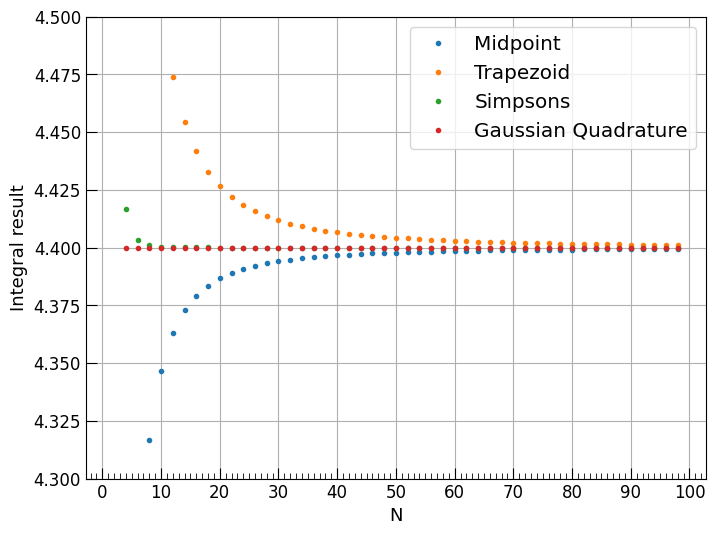

In [68]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(N_array,mid,".",label="Midpoint")
ax.plot(N_array,tra,".",label="Trapezoid")
ax.plot(N_array,sim,".",label="Simpsons")
ax.plot(N_array,gau,".",label="Gaussian Quadrature")
ax.grid(True)
ax.legend(loc='upper right', fontsize='x-large')
ax.set_xlabel("N", fontsize=13)
ax.set_ylabel("Integral result", fontsize=13)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis='both', which='major', length=8, labelsize=12,  direction = "in")
ax.tick_params(axis='both', which='minor', length=4, direction = "in")
ax.set_ylim(4.3,4.5)

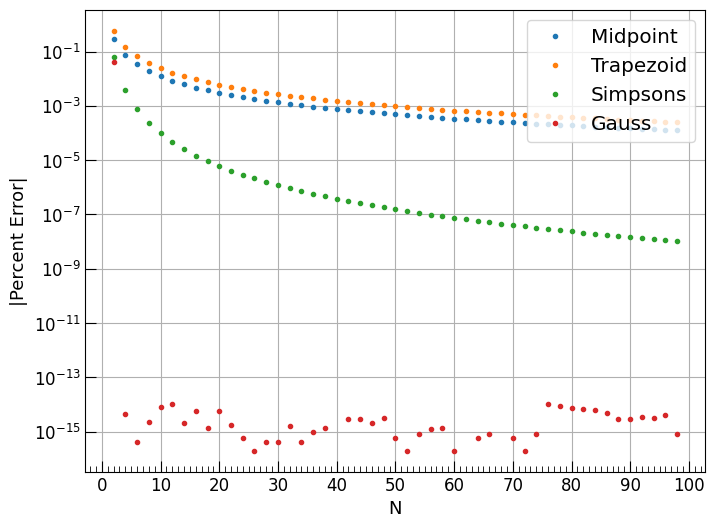

In [69]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(N_array,np.fabs(mid_pe),".",label="Midpoint")
ax.plot(N_array,np.fabs(tra_pe),".",label="Trapezoid")
ax.plot(N_array,np.fabs(sim_pe),".",label="Simpsons")
ax.plot(N_array,np.fabs(gau_pe),".",label="Gauss")
ax.grid(True)
ax.legend(loc='upper right', fontsize='x-large')
ax.set_xlabel("N", fontsize=13)
ax.set_ylabel("|Percent Error|", fontsize=13)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis='both', which='major', length=8, labelsize=12,  direction = "in")
ax.tick_params(axis='both', which='minor', length=4, direction = "in")
plt.yscale('log')


--- Visualization 2b: Legendre Polynomial P_3(x) and its Roots ---


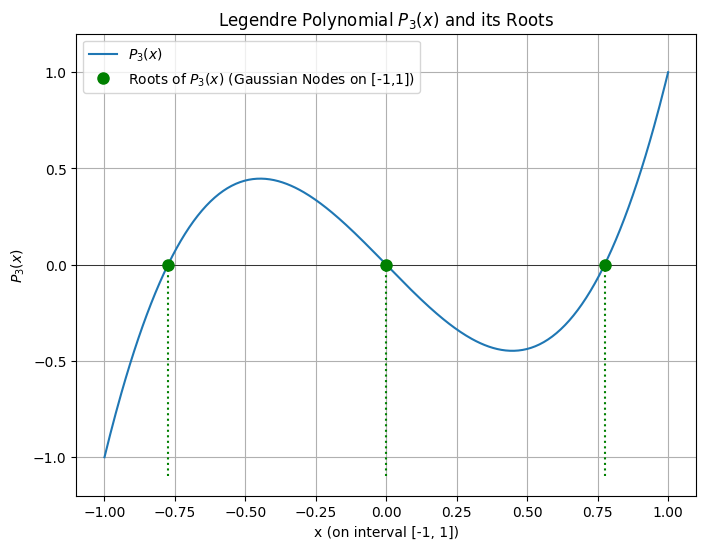

Roots of P_3(x) (Nodes on [-1, 1]): [-0.77459667  0.          0.77459667]

--- Visualization 3: Gaussian Quadrature Points (N=3) Mapped to [0.0,2.0] ---


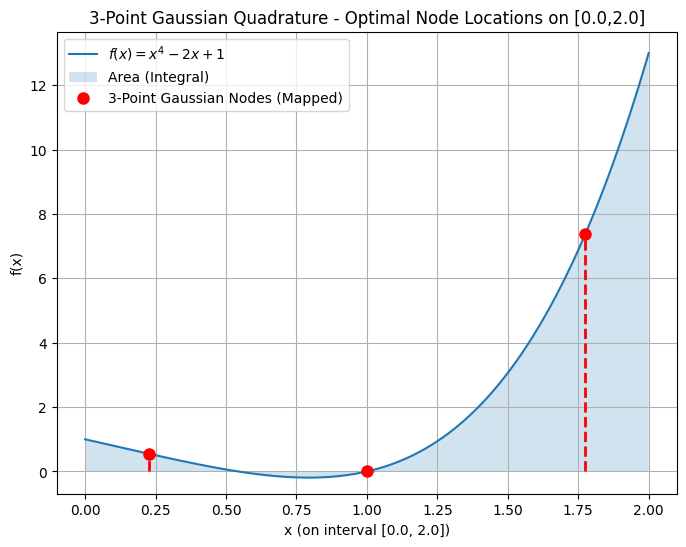

Mapped Gaussian Nodes (x_i): [0.22540333 1.         1.77459667]
Function values at nodes (f(x_i)): [0.55177466 0.         7.36822534]


In [70]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import ones,copy,cos,tan,pi,linspace

######################################################################
# Gaussian quadrature functions (from the notebook)
######################################################################
def gaussxw(N):
    """
    Calculates the sample points x and integration weights w
    for Nth-order Gaussian quadrature on the interval [-1, 1].
    Based on Mark Newman's implementation.
    Returns the nodes x_g on [-1, 1] and weights w_g.
    """
    # Initial approximation to roots of the Legendre polynomial
    a_g = linspace(3,4*N-1,N)/(4*N+2)
    x_g = cos(pi*a_g+1/(8*N*N*tan(a_g)))

    # Find roots using Newton's method
    epsilon = 1e-15
    delta = 1.0
    while delta>epsilon:
        p0 = ones(N,float)
        p1 = copy(x_g)
        for k in range(1,N):
            # Recurrence relation: (k+1)P_{k+1} = (2k+1)xP_k - kP_{k-1}
            # p0 holds P_{k-1}, p1 holds P_k. We calculate P_{k+1} and update.
            p_next = ((2*k+1)*x_g*p1 - k*p0)/(k+1)
            p0, p1 = p1, p_next
        # Now p1 holds P_N(x_g) and p0 holds P_{N-1}(x_g)

        # Derivative calculation using relation: (1-x^2)P'_N = N(P_{N-1} - xP_N)
        # Clip x_g slightly away from -1 and 1 for stability in dp calculation
        x_g_clipped = np.clip(x_g, -1 + epsilon, 1 - epsilon)
        dp = (N)*(p0 - x_g * p1) / (1 - x_g_clipped * x_g_clipped)

        # Avoid division by zero in dp if p1 happens to be zero at roots
        dp[dp == 0] = epsilon
        dx = p1/dp # Newton step dx = P_N / P'_N
        x_g -= dx
        # Ensure x_g stays strictly within [-1, 1] after Newton step
        x_g = np.clip(x_g, -1.0, 1.0)
        delta = max(abs(dx)) # Check for convergence

    # Calculate the weights using relation: w_i = 2 / ((1-x_i^2) * (P'_N(x_i))^2)
    # Re-calculate dp and clip x_g again for weight calculation stability
    x_g_clipped = np.clip(x_g, -1 + epsilon, 1 - epsilon)
    # Need P_{N-1} (p0) and P_N (p1) again at the converged roots x_g
    p0 = ones(N, float)
    p1 = copy(x_g)
    for k in range(1, N):
        p_next = ((2 * k + 1) * x_g * p1 - k * p0) / (k + 1)
        p0, p1 = p1, p_next
    dp = (N) * (p0 - x_g * p1) / (1 - x_g_clipped * x_g_clipped)

    dp[dp == 0] = epsilon # Avoid division by zero
    inner_dp_sq = dp*dp
    # Ensure denominator components for w_g are strictly positive
    inner_dp_sq[inner_dp_sq <= 0] = epsilon
    denominator_term_1_minus_xsq = 1 - x_g_clipped*x_g_clipped
    denominator_term_1_minus_xsq[denominator_term_1_minus_xsq <= 0] = epsilon

    # Original Newman formula for weights used N+1, derived from a different P' relation.
    # Using the standard P'_N relation, N replaces N+1.
    # w_g = 2 / (denominator_term_1_minus_xsq * inner_dp_sq) # Standard formula
    # Let's stick to Newman's derived formula which seemed stable in his code:
    w_g = 2*(N+1)*(N+1)/(N*N*denominator_term_1_minus_xsq*inner_dp_sq)


    return x_g,w_g


def gaussxwab(N,a,b):
    """
    Maps the sample points x and integration weights w from gaussxw(N)
    to the interval [a, b].
    """
    x_g,w_g = gaussxw(N)
    # Map points and weights to interval [a,b]
    xp = 0.5*(b-a)*x_g + 0.5*(b+a)
    wp = 0.5*(b-a)*w_g
    return xp,wp

######################################################################
# Function to calculate Legendre Polynomial P_N(x)
######################################################################
def legendre_poly(N, x):
    """ Calculates the Nth Legendre polynomial P_N(x) using recurrence. """
    if N == 0:
        return np.ones_like(x)
    elif N == 1:
        return x
    else:
        p0 = np.ones_like(x)
        p1 = x
        for k in range(1, N):
            p_next = ((2*k+1)*x*p1 - k*p0)/(k+1)
            p0, p1 = p1, p_next
        return p1 # p1 now holds P_N(x)

######################################################################
# Define the example function and interval
######################################################################
def f(x):
    """The function to integrate."""
    return x**4 - 2*x + 1

a = 0.0 # Lower bound
b = 2.0 # Upper bound
N_gauss = 3 # Number of points for Gaussian quadrature - SET TO 3
integral_true = 4.4 # Known true value for comparison

# --- Visualization 2b: Legendre Polynomial and Roots ---
print(f"\n--- Visualization 2b: Legendre Polynomial P_{N_gauss}(x) and its Roots ---")
# Get the roots (nodes) on [-1, 1]
x_roots_unmapped, _ = gaussxw(N_gauss)
x_roots_unmapped = np.sort(x_roots_unmapped) # Sort for clarity

# Generate points for plotting the polynomial
x_poly_plot = np.linspace(-1, 1, 400)
y_poly_plot = legendre_poly(N_gauss, x_poly_plot)

plt.figure(figsize=(8, 6)) # Create a new figure
plt.axhline(0, color='black', linewidth=0.5) # x-axis line
plt.plot(x_poly_plot, y_poly_plot, label=f'$P_{{{N_gauss}}}(x)$')

# Mark the roots on the x-axis
plt.plot(x_roots_unmapped, np.zeros_like(x_roots_unmapped), 'go', markersize=8, label=f'Roots of $P_{{{N_gauss}}}(x)$ (Gaussian Nodes on [-1,1])')
plt.vlines(x_roots_unmapped, plt.ylim()[0], 0, color='green', linestyle=':', lw=1.5) # Vertical lines to roots

plt.xlabel('x (on interval [-1, 1])')
plt.ylabel(f'$P_{{{N_gauss}}}(x)$')
plt.title(f'Legendre Polynomial $P_{{{N_gauss}}}(x)$ and its Roots')
plt.legend()
plt.grid(True)
plt.ylim(min(np.min(y_poly_plot)-0.2, -0.5), max(np.max(y_poly_plot)+0.2, 0.5)) # Adjust y-limits slightly
plt.show() # Display this plot

print(f"Roots of P_{N_gauss}(x) (Nodes on [-1, 1]): {x_roots_unmapped}")

# Calculate Gaussian points and weights mapped to [a, b] for subsequent plots
xp, wp = gaussxwab(N_gauss, a, b)

# Sort points and corresponding weights for consistent plotting order
sort_indices = np.argsort(xp)
xp = xp[sort_indices]
wp = wp[sort_indices]

# Calculate function values at the Gaussian nodes
yp = f(xp)

# Calculate the Gaussian quadrature approximation
gauss_approx = np.sum(wp * yp)

# --- Visualization 3: The "Clever Points" (Mapped) ---
print(f"\n--- Visualization 3: Gaussian Quadrature Points (N={N_gauss}) Mapped to [{a},{b}] ---")
plt.figure(figsize=(8, 6)) # Create a new figure for the first plot
x_smooth = np.linspace(a, b, 200) # Points for smooth function plot
y_smooth = f(x_smooth)

plt.plot(x_smooth, y_smooth, label='$f(x) = x^4 - 2x + 1$')
plt.fill_between(x_smooth, y_smooth, 0, alpha=0.2, label='Area (Integral)') # Shade area

# Highlight the Gaussian points (mapped)
plt.plot(xp, yp, 'ro', markersize=8, label=f'{N_gauss}-Point Gaussian Nodes (Mapped)')
plt.vlines(xp, 0, yp, color='red', linestyle='--', lw=2) # Vertical lines to nodes

plt.xlabel(f'x (on interval [{a}, {b}])')
plt.ylabel('f(x)')
plt.title(f'{N_gauss}-Point Gaussian Quadrature - Optimal Node Locations on [{a},{b}]')
plt.legend()
plt.grid(True)
plt.ylim(bottom=min(0, np.min(y_smooth) - 0.5)) # Ensure y=0 axis is visible
plt.show() # Display the first plot

print(f"Mapped Gaussian Nodes (x_i): {xp}")
print(f"Function values at nodes (f(x_i)): {yp}")




## SciPy Tools for Integration

Now that we know how to do numerical integration "by hand", we should also be aware that there are python libraries that can do this for us!

https://docs.scipy.org/doc/scipy/tutorial/integrate.html

https://docs.scipy.org/doc/scipy/reference/integrate.html


In [71]:
#import scipy.integrate
#help(scipy.integrate)



```
Methods for Integrating Functions given function object.

   quad          -- General purpose integration.
   dblquad       -- General purpose double integration.
   tplquad       -- General purpose triple integration.
   fixed_quad    -- Integrate func(x) using Gaussian quadrature of order n.
   quadrature    -- Integrate with given tolerance using Gaussian quadrature.
   romberg       -- Integrate func using Romberg integration.

 Methods for Integrating Functions given fixed samples.

   trapezoid            -- Use trapezoidal rule to compute integral.
   cumulative_trapezoid -- Use trapezoidal rule to cumulatively compute integral.
   simpson              -- Use Simpson's rule to compute integral from samples.
   romb                 -- Use Romberg Integration to compute integral from
                        -- (2**k + 1) evenly-spaced samples.

   See the special module's orthogonal polynomials (special) for Gaussian
      quadrature roots and weights for other weighting factors and regions.

 Interface to numerical integrators of ODE systems.

   odeint        -- General integration of ordinary differential equations.
   ode           -- Integrate ODE using VODE and ZVODE routines.
```



As you can see, `scipy.integrate` module provides several tools for numerical integration (quadrature). They generally fall into two categories: integrating functions when you have the function definition, and integrating based on fixed, sampled data points.

**1. Integrating Known Functions:**

* **`quad(func, a, b, ...)`:** The most common general-purpose integrator for single-variable functions (`func`) over a fixed interval (`a` to `b`). It uses the robust QUADPACK Fortran library (often adaptive quadrature) and provides an estimate of the integral and an upper bound on the error. It can handle infinite limits.
* **`dblquad(func, a, b, gfun, hfun, ...)`:** For double integrals over a rectangular region (defined by constants `a`, `b` and functions `gfun(y)`, `hfun(y)`).
* **`tplquad(func, a, b, gfun, hfun, qfun, rfun, ...)`:** For triple integrals over a defined volume.
* **`fixed_quad(func, a, b, n=...)`:** Computes the integral using Gaussian quadrature of a specific order `n`. Requires you to know the number of points (`n`) beforehand.
* **`quadrature(func, a, b, tol=...)`:** Uses fixed-tolerance Gaussian quadrature. It adaptively increases the order until a specified tolerance (`tol`) is met.
* **`romberg(func, a, b, tol=...)`:** Uses Romberg integration, which applies Richardson extrapolation to the trapezoid rule to improve accuracy. Good for smooth functions.

**2. Integrating Sampled Data:**

These are useful when you only have $(x_i, y_i)$ data points, not the underlying function.

* **`trapezoid(y, x=None, dx=1.0, ...)`:** Computes the integral using the composite trapezoidal rule from the $y_i$ values. You can provide corresponding $x_i$ values (for non-uniform spacing) or a constant spacing `dx`.
* **`cumulative_trapezoid(y, x=None, dx=1.0, initial=0, ...)`:** Computes the cumulative integral (like an antiderivative) using the trapezoidal rule. Returns an array of results.
* **`simpson(y, x=None, dx=1.0, ...)` or `simps(y, x=None, dx=1.0, ...)`:** Computes the integral using the composite Simpson's rule (1/3 rule). Requires an even number of intervals (odd number of points) for the standard rule, though it can handle an even number of points with adjustments. Assumes uniform spacing if only `dx` is given. Generally more accurate than `trapezoid` for smooth data *if applicable*.
* **`romb(y, dx=1.0, ...)`:** Uses Romberg integration on sampled data. Requires the number of points to be $2^k + 1$ (where $k$ is an integer) and assumes uniform spacing `dx`.

**Choosing a Method:**

* For a known function over a fixed interval: **`quad`** is usually the best starting point due to its robustness and error estimation.
* For fixed, potentially unevenly spaced data: **`trapezoid`** is the standard.
* For fixed, *evenly spaced* data (and enough points): **`simpson`** might offer better accuracy.

### General integration with SciPy - quad()

Integrate one variable between two points.

https://docs.scipy.org/doc/scipy/tutorial/integrate.html#general-integration-quad

https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html#scipy.integrate.quad


```

scipy.integrate.quad(func, a, b, args=(), full_output=0, epsabs=1.49e-08, epsrel=1.49e-08, limit=50, points=None, weight=None, wvar=None, wopts=None, maxp1=50, limlst=50, complex_func=False)

Compute a definite integral.

Integrate func from a to b (possibly infinite interval) using a technique from the Fortran library QUADPACK.


[1] Piessens, Robert; de Doncker-Kapenga, Elise; Überhuber, Christoph W.; Kahaner, David (1983). QUADPACK: A subroutine package for automatic integration. Springer-Verlag. ISBN 978-3-540-12553-2.

[2] McCullough, Thomas; Phillips, Keith (1973). Foundations of Analysis in the Complex Plane. Holt Rinehart Winston. ISBN 0-03-086370-8

    
```

* set accuracy and tolerance with epsrel and epsabs
   * epsrel (relative error tolerance) (fractional)
   * epsabs (absolute error tolerance)


* quad uses a FORTRAN library called quadpack
   * Uses 9 different methods and attempts to find an estimated integral within the error tolerance you requested

In [72]:
from scipy.integrate import quad

In [73]:
def f(x):
    return x**4 - 2*x +1

# Integrate function f between 0 and 2
quad(f,0,2)

(4.3999999999999995, 5.003996496050337e-14)

In [74]:
I = quad(f,0,2)
type(I)

tuple

In [75]:
result = I[0]  # element 0 is the estimated value of the integral
error  = I[1]  # upper bound on the error
print("Integral of f =",result," +- ",error)

Integral of f = 4.3999999999999995  +-  5.003996496050337e-14


In [76]:
from scipy import integrate

I1 , E1 = integrate.quad(f,0,2)
print("Quad integral of f =",I1," +- ",E1)


Quad integral of f = 4.3999999999999995  +-  5.003996496050337e-14


In [77]:
# If you have a function with multiple paramters you can feed them to quad with args

def f2(x,a,b,c):
    return a*x**2 + b*x +c

a = 6
b = 20
c = 2

I = quad(f2,0,2, args=(a,b,c))
print(I[0])

60.00000000000001


The following may be helpful for homework 3

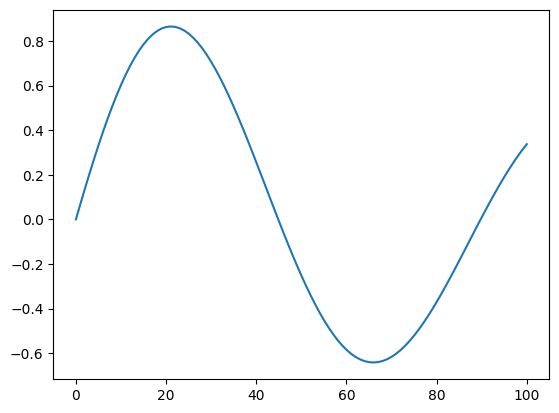

In [78]:
import numpy as np
time, velocity = np.loadtxt('http://www-personal.umich.edu/~mejn/cp/data/velocities.txt', unpack=True)

plt.plot(time,velocity)